##### 1. Use f-strings , '.format()' , and '%' formatting to produce the same output -- discuss pros/cons.

In [5]:
Name = "Abir"
Age = 27
Cgpa = 2.81

output1= f"{Name} of age {Age} has got {Cgpa}"
print(output1)

output2 = "{} of age {} has got {}".format(Name,Age,Cgpa)
print(output2)

output3 = "%s of age %d has got %.1f" %(Name, Age, Cgpa)
print(output3)

# I basically like fstrings because its easier, and easier to remember the syntax.

Abir of age 27 has got 2.81
Abir of age 27 has got 2.81
Abir of age 27 has got 2.8


#### Use list comprehensions, generator expressions, and 'map/filter' to solve the same filtering problem- compare readability and memory usage.

In [37]:
# Filter:Keep only transactions greater than $500, Apply 7% tax to those transactions and output in a format ready for a report... Transactions=> [120.50, 890.00, 45.00, 1200.75, 550.00, 20.00, 1500.00 ]

#Transactions = [120.50, 890.00, 45.00, 1200.75, 550.00, 20.00, 1500.00 ]
#list_comprehension = [round(t*1.07, 2) for t in Transactions if t>500.00 ]
#generator_expression = (round(t*1.07, 2) for t in Transactions if t> 500.00 )
#map_filter = map(lambda t:round(t* 1.07, 2),filter(lambda t:t>500.00, Transactions))
#checker = (t for t in Transactions if t>500.00 )
#taxed = (round(t*1.07,2) for t in checker)
#print(list_comprehension) #prints out the data
#print(generator_expression) #prints out the memory addresses
#print(map_filter) #prints out the memory addresses
#print(list(generator_expression))
#print(list(map_filter)) 
#print(list(taxed))

import sys
big_data = range(100000)
list_big = [y*1.07 for y in big_data if y%4==0 ]
generator_big = (y*1.07 for y in big_data if y%4==0 )
map_big = map(lambda x:x*1.07 , filter(lambda x:x%4==0, big_data))
print(f" {sys.getsizeof(list_big)} bytes")
print(f" {sys.getsizeof(generator_big)} bytes")
print(f" {sys.getsizeof(map_big)} bytes")

#Readability: List Comprehensions/Generator Expressions are left to right
            # Map/Filter are inside out

 219064 bytes
 200 bytes
 48 bytes


#### Use 'functools.lru_cache' to memoize a recursive Fibonacci function and benchmark speedup.
- **Memoization:** is caching previously computed results so that recursive functions don't recompute the same values over and over. 
- **functools.lru_cache** : 
    + **lru** = Least Recently Used (Old cache entries are discarded if the cache size is exceeded )
    + **lru_cache**: is a decorator in python that caches function results automatically.
- Fibonacci function is a function that calculates the n'th term of the Fibonacci sequence .  
     $F(1) = 1,\; F(2) = 1$   
     $F(n) = F(n-1) + F(n-2) \; ; n>2$

In [6]:
import time
from functools import lru_cache

# Recursive Fibonacci without caching
def fib_plain(n):
    if n <= 1:
        return n
    return fib_plain(n-1) + fib_plain(n-2)
# F(n) = F(n-1) + F(n-2) for n > 1
# If n = 0: returns 0 (F(0) = 0)
# If n = 1: returns 1 (F(1) = 1)

# Recursive Fibonacci with lru_cache
@lru_cache(maxsize=None)
def fib_cached(n):
    if n <= 1:
        return n
    return fib_cached(n-1) + fib_cached(n-2)

# Benchmark
n = 30

# Plain
start = time.time()
print(f"fib_plain({n}) =", fib_plain(n))
end = time.time()
print("Time without cache:", end - start, "seconds\n")

# Cached
start = time.time()
print(f"fib_cached({n}) =", fib_cached(n))
end = time.time()
print("Time with lru_cache:", end - start, "seconds")

fib_plain(30) = 832040
Time without cache: 0.17668414115905762 seconds

fib_cached(30) = 832040
Time with lru_cache: 9.465217590332031e-05 seconds


#### Chain operations using 'pandas' method chaining to clean and summarize a dataset in one expression.

- **Operations to chain:** 
    + .drop(columns=...) → remove columns
    + .rename(columns=...) → rename columns
    + .fillna(...) → fill missing values
    + .astype(...) → convert data type
    + .query(...) → filter rows
    + .assign(...) → add new column
    + .groupby(...).agg(...) → aggregation
    + .sort_values(...) → sort

In [13]:
import pandas as pd

raw = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/taxis.csv")
result = (
    pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/taxis.csv")
      # Standardize column names
      .rename(columns=lambda c: c.strip().lower())
      # Drop rows with essential missing
      .dropna(subset=["fare", "distance", "pickup"])
      # Parse date/time-- converts string-> Datetime object
      .assign(pickup_datetime=lambda df: pd.to_datetime(df["pickup"]))
      # Derive a new feature-- creates a pickup_hour column
      .assign(pickup_hour=lambda df: df["pickup_datetime"].dt.hour)
      # Filter out unrealistic values
      .query("distance > 0 and fare > 0")
      # Group & summarize--> groups rows by hour, keep pickup_hour as a column, not an index - groups are not visible, but index mapped
      .groupby("pickup_hour", as_index=False)
      #new_column_name = (source_column, operation) for each pickup_hour
      .agg(
          avg_fare=("fare", "mean"),
          avg_dist=("distance", "mean"),
          count_trips=("fare", "count")
      )
      # Sort by highest average fare
      .sort_values("avg_fare", ascending=False)
      .reset_index(drop=True)
)

print(f"Original file dataset columns:\n {raw.columns}")
print(f"Resulting dataset:\n {result}")

Original file dataset columns:
 Index(['pickup', 'dropoff', 'passengers', 'distance', 'fare', 'tip', 'tolls',
       'total', 'color', 'payment', 'pickup_zone', 'dropoff_zone',
       'pickup_borough', 'dropoff_borough'],
      dtype='object')
Resulting dataset:
     pickup_hour   avg_fare  avg_dist  count_trips
0             5  16.774510  5.134902           51
1             4  15.678571  4.501607           56
2            16  14.898503  3.305988          334
3            15  14.186758  3.255199          327
4            14  14.119716  3.145852          352
5             0  13.832512  3.661823          203
6            17  13.583099  3.087891          384
7            12  13.562636  3.174939          330
8             7  13.189680  3.348265          219
9            21  13.056130  3.208672          354
10           10  13.027377  2.765556          324
11            9  12.898019  2.714874          318
12            6  12.767445  3.445766          137
13           11  12.717551  2.668571

#### Use 'numpy' to solve a system of linear equations 'Ax=b'.
$$\begin{align}&2y_1 + y_2 = 10\\
               &y_1 + 4y_2 + y_3 = 12\\
               &y_2 + 4y_3 + y_4 = 15\\
               &y_3 + 2y_4 = 10 \end{align}$$

In [21]:
import numpy as np

A = np.array([
        [2,1,0,0],
        [1,4,1,0],
        [0, 1,4,1],
        [0,0,1,2]
    ])

# linalg.solve uses LU Decomposition with partial pivoting.
# NumPy Vectorization is boss for multivariable system solving.
# NumPy handles float precision by default.

b = np.array([10,12,15,10])
x = np.linalg.solve(A,b)
print(f"Solution Vector x: {x}")

Solution Vector x: [4.35555556 1.28888889 2.48888889 3.75555556]


#### Write a function that computes the factorial of a number using recursion and iteration. Compare performance.

In [4]:
import time
n = int(input("Enter a number: "))

def factorial_iteration(n):
    result=1
    for i in range(0,n):
        result = result * (i+1)
    return result

def factorial_recursion(n):
    if n == 0:
        return 1
    else:
        return n*factorial_recursion(n-1)

start = time.perf_counter()
for i in range(10000):
    result = factorial_iteration(n)
end = time.perf_counter()
iterative_time = end - start

start = time.perf_counter()
for i in range(10000):
    result = factorial_recursion(n)
end = time.perf_counter()
recursive_time = end - start

print(f"Iterative result: {factorial_iteration(n)}")
print(f"Recursive result: {factorial_recursion(n)}")
print(f"Iterative time: {iterative_time:.6f}")
print(f"Recursive time: {recursive_time:.6f}")

if iterative_time < recursive_time:
    print(f"Iterative time is faster by {recursive_time - iterative_time} s")
else:
    print(f"Recursive time is faster by {iterative_time - recursive_time} s")

# Iteration is generally faster, because:
# No call overhead.
# Fixed memory use.
# Becomes apparent as we increase the input number more and more.

Enter a number:  198


The value of factorial through iteration: factorial_iteration(n)
The value of factorial through recustion: factorial_recursion(n)
Iterative result: 19815524305648002601818171204326257846611456725808373449616646563928629396065410626138298593265945324225558093942704493222553838950820027765375040827960551033001579328411138624055200727234232302046524227142061137986535960488148111891395081467526982493475408477527124840709196781511817187496273890924527108598562553359394406400000000000000000000000000000000000000000000000
Recursive result: 19815524305648002601818171204326257846611456725808373449616646563928629396065410626138298593265945324225558093942704493222553838950820027765375040827960551033001579328411138624055200727234232302046524227142061137986535960488148111891395081467526982493475408477527124840709196781511817187496273890924527108598562553359394406400000000000000000000000000000000000000000000000
Iterative time: 0.184811
Recursive time: 0.318509
Iterative time is faster by 0.1336975929

#### Use 'itertools' to generate all combinations of parameters for grid search.

In [20]:
import itertools

# Define our parameter "grid"
modes = ["Heat", "Cool", "Eco"]
speeds = [1, 2, 3]
temps = [18, 22]

# Generate all combinations
# product() takes multiple iterables and returns a generator
grid = itertools.product(modes, speeds, temps)
print(type(grid))

print("Testing all configurations:")
for config in grid:
    # Each 'config' is a tuple like ("Heat", 1, 18)
    mode, speed, temp = config
    print(f"Mode: {mode}, Speed: {speed}, Temp: {temp}")


# The grid variable allows you to loop through them one at a time. It creates the   first one, gives it to you, then "forgets" it and moves to the second one.
# Writing the loop without config inside it will cause error. Because I am printi   ng mode, speed, temp variables, so can directly write it in the loop variable co  fig's place which will unpack the tuple and loop through each. 

<class 'itertools.product'>
Testing all configurations:
Mode: Heat, Speed: 1, Temp: 18
Mode: Heat, Speed: 1, Temp: 22
Mode: Heat, Speed: 2, Temp: 18
Mode: Heat, Speed: 2, Temp: 22
Mode: Heat, Speed: 3, Temp: 18
Mode: Heat, Speed: 3, Temp: 22
Mode: Cool, Speed: 1, Temp: 18
Mode: Cool, Speed: 1, Temp: 22
Mode: Cool, Speed: 2, Temp: 18
Mode: Cool, Speed: 2, Temp: 22
Mode: Cool, Speed: 3, Temp: 18
Mode: Cool, Speed: 3, Temp: 22
Mode: Eco, Speed: 1, Temp: 18
Mode: Eco, Speed: 1, Temp: 22
Mode: Eco, Speed: 2, Temp: 18
Mode: Eco, Speed: 2, Temp: 22
Mode: Eco, Speed: 3, Temp: 18
Mode: Eco, Speed: 3, Temp: 22


#### Use context managers ('with') to safely open/close files and handle exceptions. What are the other important uses of ('with')?

In [ ]:
with open("test.txt", "a") as f:
      f.write(" Hello")

##1. Database Connections (Commits & Rollbacks)
#This is probably the most important use case after files. When you talk to a database, you want to make sure your changes are saved (committed) or, if an error happens, cancelled (rolled back).
#Python
#
#import sqlite3
#
## The 'with' block manages the transaction
#with sqlite3.connect("my_data.db") as connection:
#    cursor = connection.cursor()
#    cursor.execute("INSERT INTO users VALUES ('Abir', 101)")
#    # If the code crashes here, the database won't save the broken data.
#    # If it finishes, it 'commits' automatically.
#
#2. Threading and Locks (Concurrency)
#When you have multiple parts of a program running at the same time (threads), they might try to change the same variable at once, which causes a crash. We use a Lock to make them wait their turn.
#Python
#
#from threading import Lock
#
#printer_lock = Lock()
#
#def print_securely(message):
#    with printer_lock:
#        # Only ONE thread can be inside this block at a time
#        print(message)
#    # The lock is released automatically here!
#
#3. Measuring Time (Custom Context Managers)
#You can actually create your own with statements! Remember how we used @time in Julia? We can build a "timer" in Python using with.
#Python
#
#import time
#
#class Timer:
#    def __enter__(self):
#        self.start = time.time()
#        return self
#
#    def __exit__(self, *args):
#        end = time.time()
#        print(f"Time elapsed: {end - self.start} seconds")
#
## Now you can use it like this:
#with Timer():
#    # Do some heavy calculation
#    sum(i**2 for i in range(1000000))
#
#4. Working with Network Sockets
#Just like files, network connections (sockets) are limited resources. If you open a connection to a website or another computer, you should use with to ensure it disconnects properly.
#Python
#
#import socket
#
#with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
#    s.connect(("www.google.com", 80))
#    s.sendall(b"GET / HTTP/1.1\r\n\r\n")

#### Use 'scipy.optimize.minimize' to fit a nonlinear model to synthetic data. 
*Useful to find the parameter values that minimize the Residuals (the distance between your  model's prediction and the actual data).*

In [28]:
import numpy as np
from scipy.optimize import minimize

# 1. Generate Synthetic Data
np.random.seed(42)
# linspace() is used to create an array of evenly spaced numbers.
# np.linspace(start,stop,num=50,endpoint=True(true to include the stop value as the last point),retstep=False(true to return a tuple(array, step_size)),dtype=None)
# Feature  ,  np.linspace  ,  np.arange
# Control , You control the number of points. , You control the step size.
# Reliability , Always hits the stop value exactly. , Can sometimes miss the stop   due to float precision.
# Use Case , Ideal for plotting functions or curves. , Ideal for loops or discrete  steps.

t = np.linspace(0, 5, 100)
true_A, true_k = 2.5, 1.3
# Actual signal + Gaussian noise
# Normal means normal/Gaussian/Bell distribution.
# normal(location of the mean or center of the bell, scale-> spread/how noisy the   data is , size-> shape of the output-> need one unique random value for each poi  nt in the data)
y_obs = true_A * np.exp(-true_k * t) + np.random.normal(0, 0.1, len(t))

# 2. Define the Model
def model(params, t):
    A, k = params
    return A * np.exp(-k * t)

# 3. Define Objective Function (Sum of Squared Errors)
# Optimizer tries to make this value as small as possible.
def objective(params, t, y_obs):
    y_pred = model(params, t)
    return np.sum((y_obs - y_pred)**2)

# 4. Perform Optimization
initial_guess = [1.0, 1.0]
# The minimize function only modifies the first argument of the objective function  (params). But our objective function also needs the data (t and y_data) to calculate the error. args passes that data through to the objective function without letting the optimizer try to "optimize" your time or your measurements.
result = minimize(objective, initial_guess, args=(t, y_obs))

# Extract results
# The minimize function returns a scipy.optimize.OptimizeResult object. It contains a lot of metadata:

#    success: True/False (Did it actually find a minimum?).
#   message: Why did it stop? (e.g., "Optimization terminated successfully").
#    x: This is the "treasure"—the array containing your optimized parameters.
fit_A, fit_k = result.x
print(f"Fitted Parameters: A={fit_A:.3f}, k={fit_k:.3f}")

Fitted Parameters: A=2.577, k=1.390


# Use 'matplotlib' and 'seaborn' to visualize distributions of residuals from a re  gression.

- **Regression:** is the process of finding the mathematical relationship between variables.
- **Residual:** is the distance between a data point and the regression line.
- $Residual = y_{actual}- y_{predicted}$
- If residuals follow a Normal distribution centered at 0, means missed because random noise.

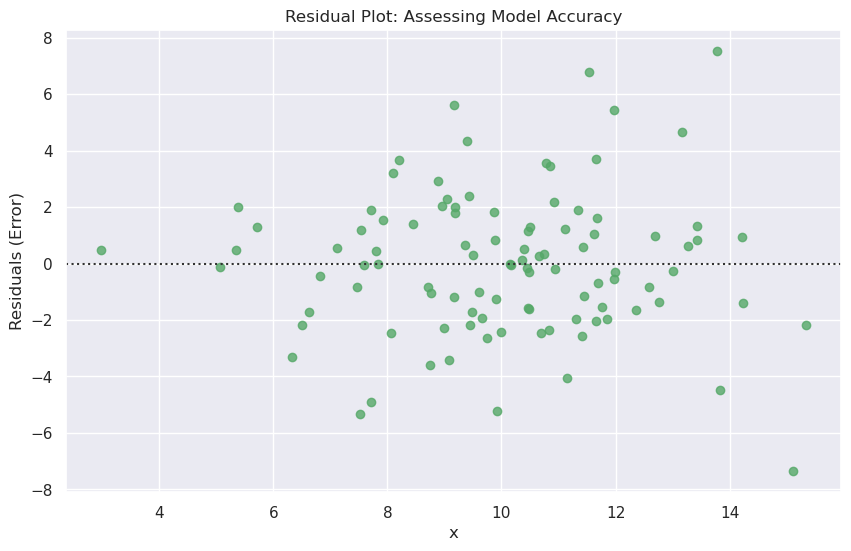

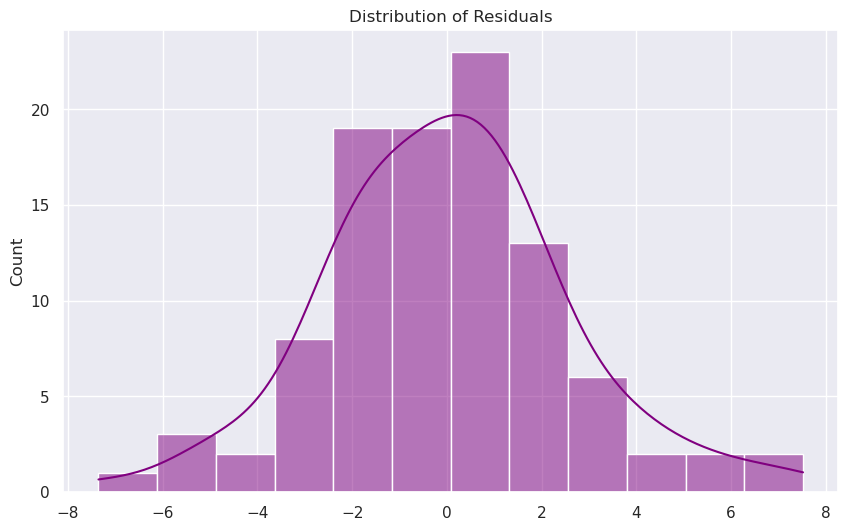

In [29]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create fake data 
np.random.seed(29)
x = np.random.normal(10, 2, 100)
# Score = 5 * hours + noise
y = 5 * x + np.random.normal(0, 3, 100)

#
# 2. Set the style 
sns.set_theme(style="darkgrid")

# 3. Plotting the Residuals
plt.figure(figsize=(10, 6))

# residplot calculates the linear regression and plots the errors
sns.residplot(x=x, y=y, color="g")

plt.title("Residual Plot: Assessing Model Accuracy")
plt.xlabel("x")
plt.ylabel("Residuals (Error)")
plt.show()

# Calculate residuals manually for the histogram
# polyfit stands for Polynomial Fit. It uses the "Method of Least Squares" to find  the coefficients for a polynomial of a specified degree.
# np.polyfit(x, y, deg)
# For degree 1, it returns: [slope, intercept]
# a, b, c = np.polyfit(x, y, 2)
slope, intercept = np.polyfit(x, y, 1)
y_pred = slope * x + intercept
residuals = y - y_pred

# Plot the distribution
plt.figure(figsize=(10, 6))
# residuals: We pass the list of errors we calculated manually.
# kde=True: This stands for Kernel Density Estimate. It draws a smooth "bell curve  " over the bars.
sns.histplot(residuals, kde=True, color="purple")
plt.title("Distribution of Residuals")
plt.show()

#### Use 'NumPy' and 'Matplotlib' to find solutions and animate a time-evolving PDE.

- **2D heat equation:**  
 $\frac{\delta }{\delta t} u[i,j] = \alpha (\frac{\delta^2 u}{\delta x^2} + \frac{\delta^2 u}{\delta y^2})$

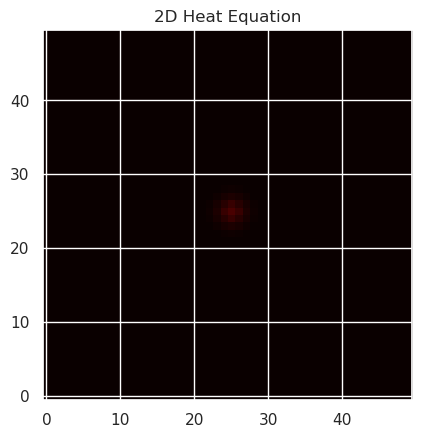

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# --- Grid parameters ---
nx, ny = 50, 50   # number of grid points
dx, dy = 1.0, 1.0 # spatial step
nt = 100          # number of time steps
dt = 0.1          # time step size
alpha = 0.1       # diffusion coefficient

# --- Initialize the field ---
u = np.zeros((nx, ny))
# initial condition: spike in the middle
u[nx//2, ny//2] = 100.0

# function to compute next time step
def step(u):
    u_new = u.copy()
    # vectorized 2D Laplacian
    u_new[1:-1, 1:-1] = u[1:-1, 1:-1] + alpha*dt*(
        (u[2:, 1:-1] - 2*u[1:-1, 1:-1] + u[:-2, 1:-1])/dx**2 +
        (u[1:-1, 2:] - 2*u[1:-1, 1:-1] + u[1:-1, :-2])/dy**2
    )
    return u_new

# --- Precompute all time steps ---
solution = [u.copy()]
for t in range(nt):
    u = step(u)
    solution.append(u.copy())

# --- Plot animation ---
fig, ax = plt.subplots()
im = ax.imshow(solution[0], cmap='hot', origin='lower', vmin=0, vmax=100)
ax.set_title("2D Heat Equation")

def update(frame):
    im.set_array(solution[frame])
    return [im]

ani = FuncAnimation(fig, update, frames=nt, blit=True)
ani.save("heat2d.gif", writer='pillow', fps=15)
plt.show()

- The animation is there in the saved gif. But jupyter is not loading it correctly.
- So the actual animation is this.
![Actual Animation GIF](heat2d.gif)

#### Use 'joblib' to parallelize a Monte Carlo simulation across CPU cores. 
- Brownian Motion simulation.
- Brownian motion in 2D using joblib

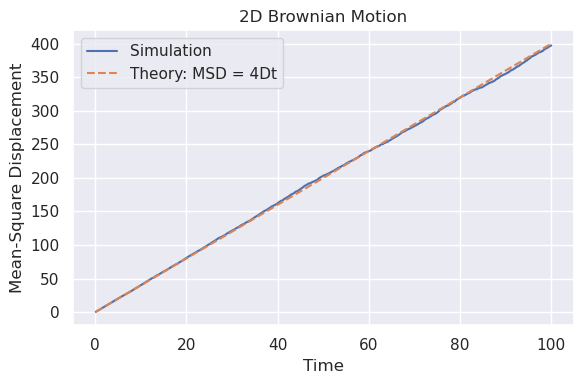

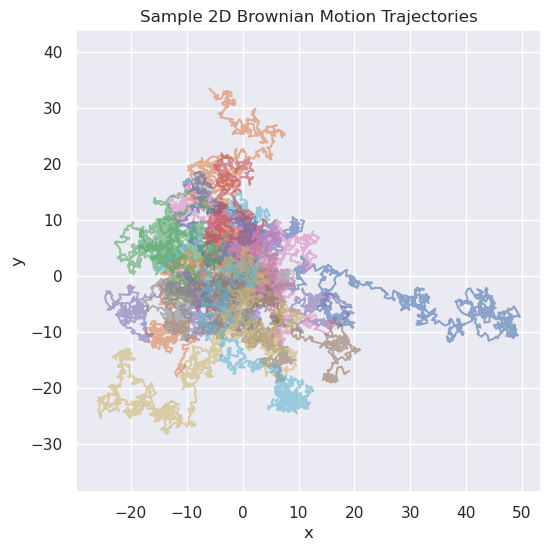

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

# --- Simulation parameters ---
n_walkers = 5000   # total number of walkers
n_steps = 1000     # steps per walker
dt = 0.1           # time step size
D = 1.0            # diffusion coefficient (variance per unit time)

# --- Function to simulate a single walker ---
def simulate_walker(steps=n_steps, dt=dt, D=D):
    # Each step is a Gaussian displacement
    displacements = np.sqrt(2*D*dt) * np.random.randn(steps, 2)
    # Cumulative sum gives trajectory
    trajectory = np.cumsum(displacements, axis=0)
    return trajectory

# --- Parallel simulation using all CPU cores ---
results = Parallel(n_jobs=-1)(delayed(simulate_walker)() for _ in range(n_walkers))

# --- Convert results into a single array ---
# shape: (n_walkers, n_steps, 2)
trajectories = np.array(results)

# --- Analysis: mean-square displacement ---
msd = np.mean(np.sum(trajectories**2, axis=2), axis=0)  # average over walkers

# --- Plot mean-square displacement ---
plt.figure(figsize=(6,4))
time = np.arange(1, n_steps+1)*dt
plt.plot(time, msd, label='Simulation')
plt.plot(time, 4*D*time, '--', label='Theory: MSD = 4Dt')
plt.xlabel('Time')
plt.ylabel('Mean-Square Displacement')
plt.title('2D Brownian Motion')
plt.legend()
plt.tight_layout()
plt.show()

# --- Optional: plot a few trajectories ---
plt.figure(figsize=(6,6))
for i in range(min(20, n_walkers)):
    plt.plot(trajectories[i,:,0], trajectories[i,:,1], alpha=0.6)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Sample 2D Brownian Motion Trajectories')
plt.axis('equal')
plt.show()

# Graph-1: Mean squared displacement(MSD) vs time,
# MSD(t): (1/N)* sum(i=1 to N) *((xi(t))**2 + (yi(t))**2) 
# Graph-2: Trajectory of the particles, Each line is a single particle's position  at each time step. 

#### Use 'heapq' to implement a priority queue for Dijkstra's shortest path algorithm.

In [36]:
import heapq

def dijkstra(graph, start):
    """
    Compute shortest distances and paths from start node to all nodes.
    
    Args:
        graph (dict): adjacency list with weights {node: [(neighbor, weight), ...], ...}
        start (str): starting node

    Returns:
        distances (dict): shortest distances from start to each node
        previous (dict): previous node in optimal path
    """
    # Initialize distances and previous node pointers
    distances = {node: float('inf') for node in graph}
    distances[start] = 0
    previous = {node: None for node in graph}

    # Priority queue: (distance, node)
    heap = [(0, start)]

    while heap:
        current_dist, current_node = heapq.heappop(heap)

        # Skip if we already found a shorter path
        if current_dist > distances[current_node]:
            continue

        for neighbor, weight in graph[current_node]:
            distance = current_dist + weight
            # Relaxation: found a shorter path
            if distance < distances[neighbor]:
                distances[neighbor] = distance
                previous[neighbor] = current_node
                heapq.heappush(heap, (distance, neighbor))

    return distances, previous


def reconstruct_path(previous, start, end):
    """
    Reconstruct shortest path from start to end using previous dict.
    
    Args:
        previous (dict): previous node pointers from Dijkstra
        start (str): start node
        end (str): end node

    Returns:
        path (list): list of nodes forming shortest path
    """
    path = []
    current = end
    while current is not None:
        path.append(current)
        current = previous[current]
    path.reverse()
    
    if path[0] == start:
        return path
    else:
        return []  # no path found


# --- Demonstration ---
if __name__ == "__main__":
    # Example weighted graph
    graph = {
        'A': [('B', 5), ('C', 1)],
        'B': [('A', 5), ('C', 2), ('D', 1)],
        'C': [('A', 1), ('B', 2), ('D', 4), ('E', 8)],
        'D': [('B', 1), ('C', 4), ('E', 3), ('F', 6)],
        'E': [('C', 8), ('D', 3)],
        'F': [('D', 6)]
    }

    start_node = 'A'
    end_node = 'F'

    distances, previous = dijkstra(graph, start_node)

    # Print distances
    print("Shortest distances from node", start_node)
    for node, dist in distances.items():
        print(f"  {node}: {dist}")

    # Print paths to each node
    print("\nShortest paths from node", start_node)
    for node in graph:
        path = reconstruct_path(previous, start_node, node)
        print(f"  {node}: {' -> '.join(path) if path else 'No path'}")

    # Example: shortest path to a specific node
    print(f"\nShortest path from {start_node} to {end_node}:")
    path = reconstruct_path(previous, start_node, end_node)
    print(" -> ".join(path) if path else "No path")

Shortest distances from node A
  A: 0
  B: 3
  C: 1
  D: 4
  E: 7
  F: 10

Shortest paths from node A
  A: A
  B: A -> C -> B
  C: A -> C
  D: A -> C -> B -> D
  E: A -> C -> B -> D -> E
  F: A -> C -> B -> D -> F

Shortest path from A to F:
A -> C -> B -> D -> F


#### Use '__slots__' in a class to reduce memory footprint for millions of instances.

- Placement new + custom memory management : `python:: __slots__`
- **Problem:**
    + Each Python object has a `__dict__` storing its attributes dynamically.
    + For millions of objects, `__dict__` adds a lot of memory overhead.
- **Solution:**
    + Use `__slots__` to predefine attributes, avoiding `__dict__` per instance.
    + This reduces memory footprint and can slightly improve attribute access speed.
- **Normal class:**
    + Each instance has a `__dict__` → dynamic attributes
    + High memory usage per object (~200–300 bytes per object for small classes)
- **Class with `__slots__`:**
    + Python pre-allocates fixed storage for attributes
    + No per-instance `__dict__`
    + Saves hundreds of bytes per object → massive memory reduction when N is large

In [38]:
import time
import sys

# Normal class
class Particle:
    def __init__(self, x, y, vx, vy):
        self.x = x
        self.y = y
        self.vx = vx
        self.vy = vy

    def update(self, dt):
        self.x += self.vx * dt
        self.y += self.vy * dt

# Memory-efficient class with __slots__
class ParticleSlots:
    __slots__ = ('x', 'y', 'vx', 'vy')

    def __init__(self, x, y, vx, vy):
        self.x = x
        self.y = y
        self.vx = vx
        self.vy = vy

    def update(self, dt):
        self.x += self.vx * dt
        self.y += self.vy * dt

# Helper: estimate memory per object
def estimate_memory(obj):
    if hasattr(obj, '__dict__'):
        return sys.getsizeof(obj) + sys.getsizeof(obj.__dict__)
    else:
        return sys.getsizeof(obj)  # __slots__ objects

# Benchmark function
def benchmark(cls, N):
    start_time = time.time()
    particles = [cls(i*0.1, i*0.1, 0.01, 0.02) for i in range(N)]
    create_time = time.time() - start_time

    start_time = time.time()
    for p in particles:
        p.update(0.1)
    update_time = time.time() - start_time

    # Estimate memory
    mem_per_instance = estimate_memory(particles[0])
    total_mem = mem_per_instance * N

    return create_time, update_time, total_mem

# Main
if __name__ == "__main__":
    N = 1_000_000  # 1 million particles

    t_create, t_update, mem = benchmark(Particle, N)
    print(f"Normal class: create {t_create:.3f}s, update {t_update:.3f}s, estimated memory {mem/1024/1024:.2f} MB")

    t_create, t_update, mem = benchmark(ParticleSlots, N)
    print(f"With __slots__: create {t_create:.3f}s, update {t_update:.3f}s, estimated memory {mem/1024/1024:.2f} MB")

# estimate_memory() manually accounts for the __dict__ in normal objects.
# For __slots__ objects, there is no __dict__, so sys.getsizeof(obj) is enough.
# This does not require any external library.
# Multiply per-object size by N to get total memory estimate.

Normal class: create 1.259s, update 0.098s, estimated memory 144.96 MB
With __slots__: create 1.060s, update 0.093s, estimated memory 61.04 MB


#### Read a large CSV in chunks using `pandas.read_csv(chunksize=...)` and aggregate statistics.
- **Dataset:** NYC Taxi and Limousine Commission (TLC) Trip Record Data (parquet data)

In [29]:
import pandas as pd
import os

PATH = os.path.expanduser('~/PaPa/MyGym/PracticeProjects/RnD_Growth/raw_data/g_patent.tsv')
CHUNK = 100_000

#COLUMNS = pd.read_csv(PATH, sep = '\t', nrows = 0)
#print(COLUMNS)
#Columns: [patent_id, patent_type, patent_date, patent_title, wipo_kind, num_claims, withdrawn, filename]

TOTAL_PATENTS = 0
PATENT_TYPE = set()
for chunk in pd.read_csv(PATH, sep = '\t', chunksize = CHUNK):
    #TOTAL_PATENTS += chunk['patent_id'].count()
    #PATENT_TYPE.update(chunk['patent_type'].unique())
#print(TOTAL_PATENTS) # 9361444
#print(PATENT_TYPE) #{'statutory invention registration', 'TVPP', 'defensive publication', 'plant', 'design', 'utility', 'reissue'}
print(len(PATENT_TYPE)) 

7


#### Use `pickle` and `joblib.dump` to save/load a trained scikit-learn model—compare size/speed.
- `Pickle` is more efficient it seems in-terms of data and speed.
- But `Joblib` is so much more easier to use.
- Maybe Joblib is the better choice in most cases, only instead of the memory heavy models in fast paced environments. 

In [6]:
import os, numpy as np
import time
import pickle
import joblib
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier

X, y = make_classification(
    n_samples=10000, 
    n_features=50, 
    n_classes=6,
    n_informative=30, 
    random_state=42
)

model = RandomForestClassifier()
model.fit(X,y)

#print(y.shape)
#print(np.unique(y))
#print(np.bincount(y))

# Pickle
pickle_save_start = time.perf_counter()
with open("model_pickle.pkl", "wb") as f:  # Write binary mode
    pickle.dump(model, f)
pickle_save_time = time.perf_counter() - pickle_save_start

pickle_load_start = time.perf_counter()
with open("model_pickle.pkl", "rb") as f:  # Read binary mode
    pickle.load(f)
pickle_load_time = time.perf_counter() - pickle_load_start

pickle_size_mb = os.path.getsize("model_pickle.pkl") / (1024 * 1024)

# Joblib
joblib_save_start = time.perf_counter()
joblib.dump(model, "model_joblib.joblib")
joblib_save_time = time.perf_counter() - joblib_save_start

joblib_start_load = time.perf_counter()
loaded_joblib_model = joblib.load("model_joblib.joblib")
joblib_load_time = time.perf_counter() - joblib_start_load

joblib_size_mb = os.path.getsize("model_joblib.joblib") / (1024 * 1024)

print(f"{'Save Time (s)':<16} | {pickle_save_time:<12.5f} | {joblib_save_time:<12.5f}")
print(f"{'Load Time (s)':<16} | {pickle_load_time:<12.5f} | {joblib_load_time:<12.5f}")
print(f"{'File Size (MB)':<16} | {pickle_size_mb:<12.3f} | {joblib_size_mb:<12.3f}")

os.remove("model_pickle.pkl")
os.remove("model_joblib.joblib")

Save Time (s)    | 0.06194      | 0.06776     
Load Time (s)    | 0.05815      | 0.08078     
File Size (MB)   | 50.184       | 50.190      


#### Clean a messy dataset: handle missing values, outliers, and inconsistent categories using `pandas`.

#### Merge two datasets on a key with different join types (inner, left, outer)—explain use cases.

#### Convert JSON lines to a pandas DataFrame and extract nested fields.

#### Use `dask.dataframe` to process a dataset larger than RAM.

#### Encode categorical variables using one-hot, label, and target encoding—compare impact on ML model.

#### Use `snakemake` or `make` to orchestrate a data preprocessing → modeling → evaluation pipeline.

#### Use `subprocess` to call external tools (e.g., `ffmpeg`, `gdal`) from within a data workflow.

#### Automate renaming thousands of image files using regex and `pathlib`.

#### Use `click` to build a CLI tool that trains a model with configurable hyperparameters.

#### Embed a lightweight HTTP server (`http.server`) to serve model predictions as JSON.

#### Use `ctypes` to call a compiled C function (e.g., from a `.so`) for fast math.

#### Compare memory usage between loading a 10M-row CSV using list comprehension vs generator. Implement a custom LazyDataLoader that yields batches from a file without loading it entirely into RAM.